In [1]:
import cmocean
import numpy as np 
import xarray as xr
import pandas as pd 
import seaborn as sns
import cartopy.crs as ccrs
import statsmodels.api as sm
import matplotlib.pyplot as plt
from IPython.display import HTML
from scipy.stats import linregress 
from nemo_cookbook import NEMODataTree 
from matplotlib.patches import Rectangle
from OceanDataStore import OceanDataCatalog 
from matplotlib.animation import FuncAnimation

In [4]:
# Open model and config files

catalog = OceanDataCatalog(catalog_name='noc-model-stac')
catalog.search(collection='noc-npd-era5')
ds1_annual = catalog.open_dataset(id=catalog.Items[18].id,
                          start_datetime='1990-01',
                          end_datetime='2024-12')

catalog.search(collection='noc-npd-era5', item_name='domain_cfg')
config = catalog.open_dataset(id=catalog.Items[1].id)

# Merge into a data tree
datasets_annual = {'parent': {'domain': config, 'gridT': ds1_annual}}
dt_global_annual = NEMODataTree.from_datasets(datasets = datasets_annual)

# Clip to North Atlantic 
bbox = (-85.0, 0.0, 0.0, 80.0)
dt_annual = dt_global_annual.clip_grid(grid='/gridT', bbox=bbox)


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1y
              Title: eORCA1 ERA5v1 NPD T1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/U1y
              Title: eORCA1 ERA5v1 NPD U1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at U-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/V1y
              Title: eORCA1 ERA5v1 NPD V1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global oc

In [15]:
# Correct compatibility error 
dt_annual['/gridT']['tmaskutil'] = dt_annual['/gridT']['tmaskutil'].astype(bool)

In [31]:
dt_annual['/gridT']['salinity_0'] = dt_annual['/gridT']['so_abs'].sel(deptht = 0, method = 'nearest')
dt_annual['/gridT']['salinity_50'] = dt_annual['/gridT']['so_abs'].sel(deptht = 50, method = 'nearest')
dt_annual['/gridT']['salinity_100'] = dt_annual['/gridT']['so_abs'].sel(deptht = 100, method = 'nearest')
dt_annual['/gridT']['salinity_200'] = dt_annual['/gridT']['so_abs'].sel(deptht = 200, method = 'nearest')
dt_annual['/gridT']['salinity_500'] = dt_annual['/gridT']['so_abs'].sel(deptht = 500, method = 'nearest')
dt_annual['/gridT']['salinity_1000'] = dt_annual['/gridT']['so_abs'].sel(deptht = 1000, method = 'nearest')


In [32]:
weighted_mean_0 = dt_annual.masked_statistic(grid='/gridT', var='salinity_0', lon_poly = [-35.0, -35.0, -25.0, -25.0, -35.0], lat_poly = [52.0, 58.0, 58.0, 52.0, 52.0], statistic="weighted_mean", dims=["i", "j"])
weighted_mean_50 = dt_annual.masked_statistic(grid='/gridT', var='salinity_50', lon_poly = [-35.0, -35.0, -25.0, -25.0, -35.0], lat_poly = [52.0, 58.0, 58.0, 52.0, 52.0], statistic="weighted_mean", dims=["i", "j"])
weighted_mean_100 = dt_annual.masked_statistic(grid='/gridT', var='salinity_100', lon_poly = [-35.0, -35.0, -25.0, -25.0, -35.0], lat_poly = [52.0, 58.0, 58.0, 52.0, 52.0], statistic="weighted_mean", dims=["i", "j"])
weighted_mean_200 = dt_annual.masked_statistic(grid='/gridT', var='salinity_200', lon_poly = [-35.0, -35.0, -25.0, -25.0, -35.0], lat_poly = [52.0, 58.0, 58.0, 52.0, 52.0], statistic="weighted_mean", dims=["i", "j"])
weighted_mean_500 = dt_annual.masked_statistic(grid='/gridT', var='salinity_500', lon_poly = [-35.0, -35.0, -25.0, -25.0, -35.0], lat_poly = [52.0, 58.0, 58.0, 52.0, 52.0], statistic="weighted_mean", dims=["i", "j"])
weighted_mean_1000 = dt_annual.masked_statistic(grid='/gridT', var='salinity_1000', lon_poly = [-35.0, -35.0, -25.0, -25.0, -35.0], lat_poly = [52.0, 58.0, 58.0, 52.0, 52.0], statistic="weighted_mean", dims=["i", "j"])


In [33]:
weighted_mean_0.to_netcdf('salinity_0.nc')
print('0')
weighted_mean_50.to_netcdf('salinity_50.nc')
print('1')
weighted_mean_100.to_netcdf('salinity_100.nc')
print('2')
weighted_mean_200.to_netcdf('salinity_200.nc')
print('3')
weighted_mean_500.to_netcdf('salinity_500.nc')
print('4')
weighted_mean_1000.to_netcdf('salinity_1000.nc')

0
1
2
3
4


In [40]:
## Start from here in future 

salinity_0 = xr.open_dataset('salinity_0.nc')['salinity_0']
salinity_50 = xr.open_dataset('salinity_50.nc')['salinity_50']
salinity_100 = xr.open_dataset('salinity_100.nc')['salinity_100']
salinity_200 = xr.open_dataset('salinity_200.nc')['salinity_200']
salinity_500 = xr.open_dataset('salinity_500.nc')['salinity_500']
salinity_1000 = xr.open_dataset('salinity_1000.nc')['salinity_1000']

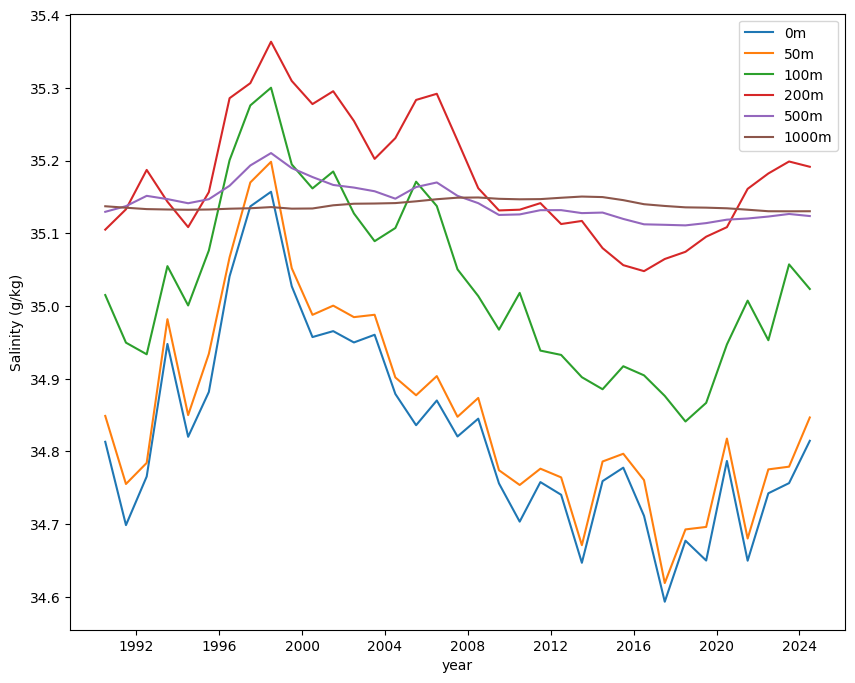

<Figure size 640x480 with 0 Axes>

In [46]:
fig, ax = plt.subplots(figsize = (10, 8))

ax.plot(salinity_0['time_counter'], salinity_0, label = '0m')
ax.plot(salinity_50['time_counter'], salinity_50, label = '50m')
ax.plot(salinity_100['time_counter'], salinity_100, label = '100m')
ax.plot(salinity_200['time_counter'], salinity_200, label = '200m')
ax.plot(salinity_500['time_counter'], salinity_500, label = '500m')
ax.plot(salinity_1000['time_counter'], salinity_1000, label = '1000m')

ax.set_xlabel('year')
ax.set_ylabel('Salinity (g/kg)')

plt.legend(loc = 'best')
plt.show()
plt.savefig('Budget Region Annual Salinity with depth.png')